# 2. Data Preparation & Understanding

In [ ]:
# 1) SETUP + LOAD DATA
# =========================
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

# --- Option A: Upload file directly in Colab ---
# The files.upload() function is typically for interactive upload.
# If the file is already at a known path, you can directly read it.
# uploaded = files.upload("/content/synthetic_fraud_dataset.csv") # Corrected syntax, but not needed if file is already there

# Find the uploaded CSV filename (this part assumes a file was interactively uploaded, which is not the case here)
# csv_name = [k for k in uploaded.keys() if k.lower().endswith(".csv")][0]
df = pd.read_csv("/content/synthetic_fraud_dataset.csv") # Corrected syntax: added quotes around the file path

print("Shape:", df.shape)
df.head()

2) Dataset Understanding (Business Summary)

In [ ]:
# =========================
# 2) UNDERSTANDING THE DATA
# =========================
print(df.info())

# Business-friendly column dictionary (edit wording if you want)
business_dictionary = {
    "transaction_id": "Unique identifier for each transaction (operational tracking; not behavior).",
    "user_id": "Customer/account identifier (useful for aggregation, not direct clustering).",
    "amount": "Transaction amount in currency units (spend intensity).",
    "transaction_type": "Channel/type (e.g., POS, Online, ATM, QR) – indicates purchase behavior.",
    "merchant_category": "Merchant category (Food, Travel, Grocery, etc.) – spending domain.",
    "country": "Country of transaction – geographic pattern and risk context.",
    "hour": "Hour of day (0–23) – timing/behavior and potential fraud risk.",
    "device_risk_score": "Device-level risk score (0–1) – higher may indicate suspicious device context.",
    "ip_risk_score": "IP/network risk score (0–1) – higher may indicate risky network origin.",
    "is_fraud": "Binary fraud label (1 = fraud). Use ONLY for profiling after clustering."
}

print("\nBusiness Dictionary:")
for k in df.columns:
    print(f"- {k}: {business_dictionary.get(k, 'No description added')}")

# Missing values check
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_table = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_table


Feature Engineering (Business Relevant)

In [ ]:
# =========================
# 3) FEATURE ENGINEERING
# =========================
df_fe = df.copy()

# Safe log transform
df_fe["log_amount"] = np.log1p(df_fe["amount"])

# Combine risk signals
df_fe["risk_sum"] = df_fe["device_risk_score"] + df_fe["ip_risk_score"]
df_fe["risk_mean"] = (df_fe["device_risk_score"] + df_fe["ip_risk_score"]) / 2

# High amount flag (business: unusually high purchase)
threshold = df_fe["amount"].quantile(0.90)
df_fe["high_amount_flag"] = (df_fe["amount"] >= threshold).astype(int)

df_fe.head()


#3. Predictive Analytics (Supervised Learning)

1. Loading Data

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('/content/synthetic_fraud_dataset.csv')  # your code here
df.head()

2. Data Preprocessing

In [ ]:
print("\n--- Missing Values Check ---")
print(df.isna().sum())

# Feature Engineering: Convert categorical variables to numeric (One-Hot Encoding)
# Using pd.get_dummies as preferred in your MP assignments
categorical_cols = ['transaction_type', 'merchant_category', 'country']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Define Features (X) and Target (y)
target = 'is_fraud'
# Drop ID columns as they are not useful for prediction
drop_cols = ['transaction_id', 'user_id', target]
X = df_encoded.drop(columns=drop_cols)
y = df_encoded[target]

3. Train/Test Split

In [ ]:
# Use stratify=y to maintain the ratio of fraud cases
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print(f"\nTrain set size: {X_train.shape}, Test set size: {X_test.shape}")

4. Model Training & Evaluation

In [ ]:
# Define the three models we want to compare
models = {
    "Logistic Regression": LogisticRegression(solver='liblinear', random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
}

results = []
confusion_matrices = {}

print("\n--- Starting Model Training ---")

for name, model in models.items():
    # Fit the model
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Calculate metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Store results
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1
    })

    # Store confusion matrix for later use
    confusion_matrices[name] = confusion_matrix(y_test, y_pred)

    print(f"{name} -> Accuracy: {acc:.4f}, F1: {f1:.4f}")

5. Results Presentation (Comparison Tables)

In [ ]:
results_df = pd.DataFrame(results)
print("\n--- Model Performance Comparison ---")
display(results_df)

# Visualization (Bar Chart)
# Plotting F1-Score comparison
plt.figure(figsize=(10, 6))
# We can use Pandas plotting directly
results_df.set_index("Model")[["Accuracy", "Recall", "F1-Score"]].plot(kind="bar", figsize=(10, 6))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--')
plt.legend(loc='lower right')
plt.show()

6. Business Dashboard: Profit/Loss Analysis

In [ ]:
# Business Assumptions:
# - Missed Fraud (FN): We lose the fraud amount. Avg = $1000.
# - False Alarm (FP): We insult a customer. Cost = $20 (support cost/churn risk).
# - Caught Fraud (TP): We save the money. Savings = $1000.

AVG_FRAUD_AMOUNT = 1000
COST_FALSE_ALARM = 20

print("\n--- Business Impact Analysis ---")

for name, cm in confusion_matrices.items():
    tn, fp, fn, tp = cm.ravel()

    # Calculate financial impact
    # Savings: Money we didn't lose because we stopped the fraud
    savings = tp * AVG_FRAUD_AMOUNT

    # Costs: Money lost due to missed fraud + Money wasted on false alarms
    loss_missed = fn * AVG_FRAUD_AMOUNT
    cost_false_alarm = fp * COST_FALSE_ALARM

    # Net Impact: Total Savings - Total Costs (False Alarms)
    # Note: Usually we compare "Net Savings" against doing nothing.
    net_benefit = savings - cost_false_alarm

    print(f"\nModel: {name}")
    print(f"  Confusion Matrix: TN={tn}, FP={fp}, FN={fn}, TP={tp}")
    print(f"  > Total Savings (Fraud Stopped): ${savings:,.0f}")
    print(f"  > Operational Costs (False Alarms): -${cost_false_alarm:,.0f}")
    print(f"  > Net Business Benefit: ${net_benefit:,.0f}")

    # Plot Confusion Matrix
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} - Confusion Matrix")
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()

#4. Exploratory Data Analysis (Tables)

In [ ]:
# =========================
# 4) EDA: TABLES + VISUALS
# =========================

# Basic descriptive stats for numeric columns
numeric_cols = df_fe.select_dtypes(include=[np.number]).columns.tolist()
df_fe[numeric_cols].describe().T


A) Transaction Mix by Type/ Category/ Country

In [ ]:
def top_counts_table(col, top_n=10):
    out = df[col].value_counts().head(top_n).to_frame("count")
    out["pct"] = (out["count"] / len(df) * 100).round(2)
    return out

print("Top transaction types:")
display(top_counts_table("transaction_type"))

print("Top merchant categories:")
display(top_counts_table("merchant_category"))

print("Top countries:")
display(top_counts_table("country"))

In [ ]:
print("Descriptive statistics for numerical columns:")
display(df.describe())

In [ ]:
print("Descriptive statistics for categorical columns:")
display(df.select_dtypes(include='object').describe())

B) Visuals : amount distribution + hourly

In [ ]:
plt.figure()
df_fe["amount"].hist(bins=50)
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Count")
plt.show()

plt.figure()
df_fe["hour"].value_counts().sort_index().plot(kind="bar")
plt.title("Transactions by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Count")
plt.show()


Risk vs. Amount (high spend + high risk)

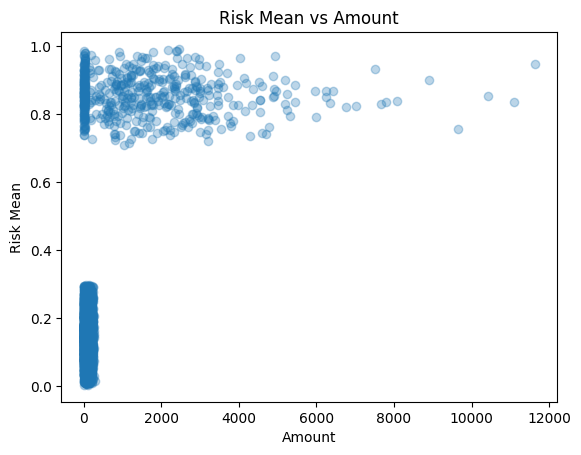

In [ ]:
plt.figure()
plt.scatter(df_fe["amount"], df_fe["risk_mean"], alpha=0.3)
plt.title("Risk Mean vs Amount")
plt.xlabel("Amount")
plt.ylabel("Risk Mean")
plt.show()


D) Fraud Label, business profile

Overall fraud rate: 5.000%


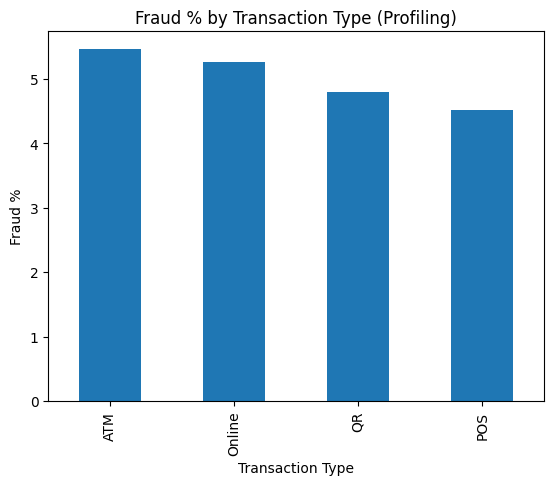

In [ ]:
if "is_fraud" in df_fe.columns:
    fraud_rate = df_fe["is_fraud"].mean()
    print(f"Overall fraud rate: {fraud_rate:.3%}")

    # Fraud rate by transaction type
    fraud_by_type = df_fe.groupby("transaction_type")["is_fraud"].agg(["mean","count"]).sort_values("mean", ascending=False)
    fraud_by_type["mean"] = (fraud_by_type["mean"]*100).round(2)
    fraud_by_type.rename(columns={"mean":"fraud_%", "count":"n"}, inplace=True)
    fraud_by_type

    plt.figure()
    fraud_by_type["fraud_%"].plot(kind="bar")
    plt.title("Fraud % by Transaction Type (Profiling)")
    plt.xlabel("Transaction Type")
    plt.ylabel("Fraud %")
    plt.show()


5) Preprocessing for Clustering (Input + Encode + Scale)

In [ ]:
# =========================
# 5) PREPROCESSING PIPELINE
# =========================
target_col = "is_fraud" if "is_fraud" in df_fe.columns else None

drop_cols = ["transaction_id", "user_id"]
if target_col:
    drop_cols.append(target_col)

X = df_fe.drop(columns=[c for c in drop_cols if c in df_fe.columns], errors="ignore")

# Separate column types
num_features = X.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numeric features:", num_features)
print("Categorical features:", cat_features)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_features),
        ("cat", categorical_transformer, cat_features),
    ]
)


Numeric features: ['amount', 'hour', 'device_risk_score', 'ip_risk_score', 'high_amount', 'night_txn', 'risk_index', 'log_amount', 'risk_sum', 'risk_mean', 'high_amount_flag']
Categorical features: ['transaction_type', 'merchant_category', 'country']


6) K-Means Clustering + Evaluation (elbow + Silhouette)

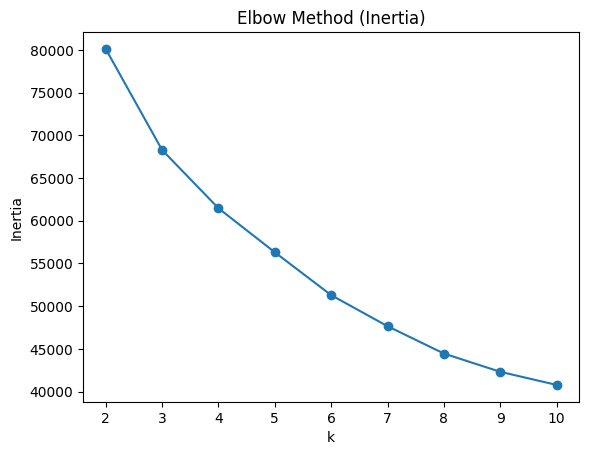

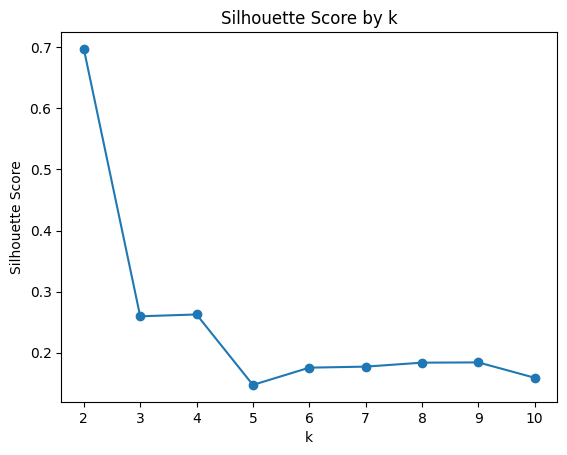

Best k by silhouette: 2


In [ ]:
# =========================
# 6) KMEANS + EVALUATION
# =========================

# Transform features
X_processed = preprocess.fit_transform(X)

# Elbow + Silhouette across k values
ks = range(2, 11)
inertias = []
silhouettes = []

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_processed)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_processed, labels))

plt.figure()
plt.plot(list(ks), inertias, marker="o")
plt.title("Elbow Method (Inertia)")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.show()

plt.figure()
plt.plot(list(ks), silhouettes, marker="o")
plt.title("Silhouette Score by k")
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.show()

best_k = ks[int(np.argmax(silhouettes))]
print("Best k by silhouette:", best_k)


7) Fit Final K-Means + Cluster Profiling

In [ ]:
# =========================
# 7) FINAL MODEL + PROFILING
# =========================
k = best_k  # or set manually, e.g., k=4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_processed)

df_out = df_fe.copy()
df_out["cluster"] = cluster_labels

# Cluster size
cluster_sizes = df_out["cluster"].value_counts().sort_index().to_frame("n")
cluster_sizes["pct"] = (cluster_sizes["n"] / len(df_out) * 100).round(2)
cluster_sizes


,n,pct
cluster,,
0,9500,95.0
1,500,5.0


A) Numeric Feature profiles by Cluster

In [ ]:
profile_numeric = df_out.groupby("cluster")[[
    "amount","log_amount","hour","device_risk_score","ip_risk_score","risk_sum","risk_mean","high_amount_flag"
]].agg(["mean","median"])

profile_numeric


amount              log_amount                 hour         \
                mean       median       mean    median       mean median   
cluster                                                                    
0         100.277751   100.288774   4.399628  4.617976  14.469684   14.0   
1        1657.577984  1220.563618   6.130736  7.107887  10.018000    9.0   

        device_risk_score           ip_risk_score            risk_sum  \
                     mean    median          mean    median      mean   
cluster                                                                 
0                0.148290  0.148586      0.149558  0.150320  0.297848   
1                0.857951  0.855294      0.851770  0.856042  1.709721   

                  risk_mean           high_amount_flag         
           median      mean    median             mean median  
cluster                                                        
0        0.297554  0.148924  0.148777         0.067579    0.0  
1        1.708189  0.854860  0.854094         0.716000    1.0

B) Top Categories per cluster (transaction type/ merchant category/ country)

In [ ]:
def top_categories_by_cluster(df, col, top_n=3):
    rows = []
    for cl in sorted(df["cluster"].unique()):
        vc = df[df["cluster"] == cl][col].value_counts().head(top_n)
        rows.append({
            "cluster": cl,
            "top_values": ", ".join([f"{idx} ({cnt})" for idx, cnt in vc.items()])
        })
    return pd.DataFrame(rows)

display(top_categories_by_cluster(df_out, "transaction_type"))
display(top_categories_by_cluster(df_out, "merchant_category"))
display(top_categories_by_cluster(df_out, "country"))


,cluster,top_values
0,0,"POS (2452), ATM (2391), QR (2386)"
1,1,"ATM (138), Online (126), QR (120)"


,cluster,top_values
0,0,"Food (1931), Travel (1909), Electronics (1909)"
1,1,"Clothing (109), Travel (106), Electronics (98)"


,cluster,top_values
0,0,"US (1953), FR (1953), UK (1880)"
1,1,"NG (100), US (97), UK (85)"


C) Fraud rate by cluster

In [ ]:
if "is_fraud" in df_out.columns:
    fraud_by_cluster = df_out.groupby("cluster")["is_fraud"].agg(["mean","count"]).rename(columns={"mean":"fraud_rate","count":"n"})
    fraud_by_cluster["fraud_rate"] = (fraud_by_cluster["fraud_rate"]*100).round(2)
    fraud_by_cluster.rename(columns={"fraud_rate":"fraud_%"} , inplace=True)
    fraud_by_cluster


8) Hierarchical Clustering

In [ ]:
# =========================
# 8) OPTIONAL HIERARCHICAL (SAMPLED)
# =========================
sample_n = 1500

# Sample indices from the processed data X, which is a numpy array
sample_indices = np.random.choice(X.shape[0], size=sample_n, replace=False)
X_sample_processed = X[sample_indices]

hc = AgglomerativeClustering(n_clusters=best_k, linkage="ward")
hc_labels = hc.fit_predict(X_sample_processed)

print("Hierarchical silhouette:", silhouette_score(X_sample_processed, hc_labels))

Hierarchical silhouette: 0.6952567896202154


In [ ]:
# Step 1.1: Load dataset
df = pd.read_csv("synthetic_fraud_dataset.csv")

# Step 1.2: Basic structure
print("Shape (rows, columns):", df.shape)
print("\nColumns:", df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

# Step 1.3: Numeric summary
print("\nNumeric summary:")
display(df.describe())

# Step 1.4: Categorical summaries
cat_cols = ['transaction_type', 'merchant_category', 'country']
for col in cat_cols:
    print(f"\nValue counts for {col}:")
    print(df[col].value_counts().head(10))

# Step 1.5: Fraud rate
fraud_rate = df['is_fraud'].mean()
print(f"\nOverall fraud rate: {fraud_rate:.2%}")


Shape (rows, columns): (10000, 10)

Columns: ['transaction_id', 'user_id', 'amount', 'transaction_type', 'merchant_category', 'country', 'hour', 'device_risk_score', 'ip_risk_score', 'is_fraud']

First 5 rows:


,transaction_id,user_id,amount,transaction_type,merchant_category,country,hour,device_risk_score,ip_risk_score,is_fraud
0,9608,363,4922.587542,ATM,Travel,TR,12,0.992347,0.947908,1
1,456,692,48.018303,QR,Food,US,21,0.168571,0.224057,0
2,4747,587,136.881960,Online,Travel,TR,14,0.296127,0.125058,0
3,6934,445,80.534719,POS,Clothing,TR,23,0.124801,0.159243,0
4,1646,729,120.041158,Online,Grocery,FR,16,0.098129,0.027542,0



Numeric summary:


,transaction_id,user_id,amount,hour,device_risk_score,ip_risk_score,is_fraud
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4999.50000,500.058700,178.142763,14.247100,0.183773,0.184669,0.050000
std,2886.89568,288.328495,531.647950,5.347383,0.177381,0.175772,0.217956
min,0.00000,0.000000,1.000000,0.000000,0.000030,0.000009,0.000000
25%,2499.75000,247.000000,65.084753,10.000000,0.075721,0.077762,0.000000
50%,4999.50000,503.000000,101.686510,14.000000,0.156583,0.158290,0.000000
75%,7499.25000,750.250000,138.280872,19.000000,0.234939,0.236968,0.000000
max,9999.00000,999.000000,11628.213881,23.000000,0.998737,0.999603,1.000000



Value counts for transaction_type:
transaction_type
POS       2568
ATM       2529
QR        2506
Online    2397
Name: count, dtype: int64

Value counts for merchant_category:
merchant_category
Food           2023
Travel         2015
Electronics    2007
Clothing       1982
Grocery        1973
Name: count, dtype: int64

Value counts for country:
country
US    2050
FR    2027
UK    1965
DE    1930
TR    1928
NG     100
Name: count, dtype: int64

Overall fraud rate: 5.00%


9) Business Interpretation

In [ ]:
# =========================
# 9) INTERPRETATION HELPER
# =========================
# Quick summary table (one row per cluster)
summary = df_out.groupby("cluster").agg(
    n=("cluster","size"),
    avg_amount=("amount","mean"),
    med_amount=("amount","median"),
    avg_risk=("risk_mean","mean"),
    high_amount_rate=("high_amount_flag","mean"),
    avg_hour=("hour","mean")
).reset_index()

summary["high_amount_rate"] = (summary["high_amount_rate"]*100).round(2)
summary["avg_amount"] = summary["avg_amount"].round(2)
summary["med_amount"] = summary["med_amount"].round(2)
summary["avg_risk"] = summary["avg_risk"].round(3)
summary["avg_hour"] = summary["avg_hour"].round(1)

summary


,cluster,n,avg_amount,med_amount,avg_risk,high_amount_rate,avg_hour
0,0,9500,100.28,100.29,0.149,6.76,14.5
1,1,500,1657.58,1220.56,0.855,71.60,10.0


In [ ]:
# Step 2.2: Feature engineering
# High amount flag (above 75th percentile)
amount_q75 = df['amount'].quantile(0.75)
df['high_amount'] = (df['amount'] > amount_q75).astype(int)

# Night-time transaction (0–5 hours)
df['night_txn'] = df['hour'].isin([0, 1, 2, 3, 4, 5]).astype(int)

# Combined risk index from device & IP
df['risk_index'] = (df['device_risk_score'] + df['ip_risk_score']) / 2

df[['amount', 'high_amount', 'hour', 'night_txn', 'device_risk_score', 'ip_risk_score', 'risk_index']].head()


,amount,high_amount,hour,night_txn,device_risk_score,ip_risk_score,risk_index
0,4922.587542,1,12,0,0.992347,0.947908,0.970127
1,48.018303,0,21,0,0.168571,0.224057,0.196314
2,136.881960,0,14,0,0.296127,0.125058,0.210592
3,80.534719,0,23,0,0.124801,0.159243,0.142022
4,120.041158,0,16,0,0.098129,0.027542,0.062835


Define Feature & Preprocessing (Scaling + one hot encoding)

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Step 2.2: Feature engineering
# High amount flag (above 75th percentile)
amount_q75 = df['amount'].quantile(0.75)
df['high_amount'] = (df['amount'] > amount_q75).astype(int)

# Night-time transaction (0–5 hours)
df['night_txn'] = df['hour'].isin([0, 1, 2, 3, 4, 5]).astype(int)

# Combined risk index from device & IP
df['risk_index'] = (df['device_risk_score'] + df['ip_risk_score']) / 2

# Step 2.3: Define feature sets
numeric_features = [
    'amount', 'hour', 'device_risk_score', 'ip_risk_score',
    'high_amount', 'night_txn', 'risk_index'
]

categorical_features = ['transaction_type', 'merchant_category', 'country']

# Step 2.4: ColumnTransformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ]
)

# Step 2.5: Fit and transform
X = preprocessor.fit_transform(df)

print("Processed feature matrix shape:", X.shape)

Processed feature matrix shape: (10000, 19)


Define Transaction Types

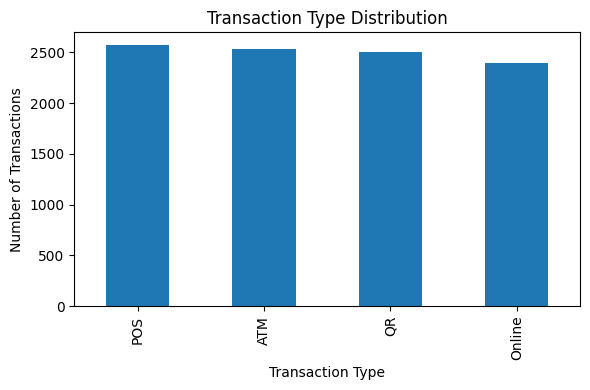

In [ ]:
# Step 3.1: Transaction type distribution
tt_counts = df['transaction_type'].value_counts()

plt.figure(figsize=(6,4))
tt_counts.plot(kind='bar')
plt.title("Transaction Type Distribution")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()


Fraud Rate by Transaction Type

Fraud rate by transaction type:
transaction_type
ATM       0.054567
Online    0.052566
QR        0.047885
POS       0.045171
Name: is_fraud, dtype: float64


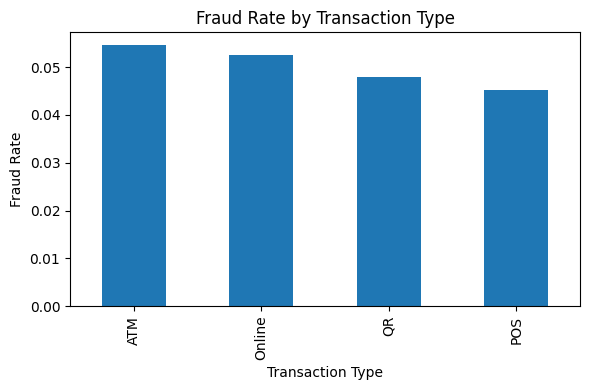

In [ ]:
# Step 3.2: Fraud rate by transaction type
fraud_by_type = df.groupby('transaction_type')['is_fraud'].mean().sort_values(ascending=False)
print("Fraud rate by transaction type:")
print(fraud_by_type)

plt.figure(figsize=(6,4))
fraud_by_type.plot(kind='bar')
plt.title("Fraud Rate by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Fraud Rate")
plt.tight_layout()
plt.show()


Fraud Rate by Merchant Category

Fraud rate by top merchant categories:
merchant_category
Clothing       0.054995
Travel         0.052605
Electronics    0.048829
Grocery        0.048150
Food           0.045477
Name: is_fraud, dtype: float64


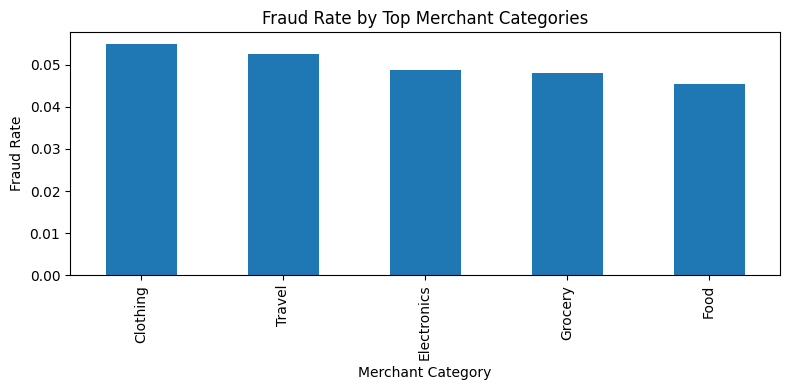

In [ ]:
# Step 3.3: Fraud rate by top merchant categories
top_merchants = df['merchant_category'].value_counts().head(10).index
fraud_by_merchant = (
    df[df['merchant_category'].isin(top_merchants)]
    .groupby('merchant_category')['is_fraud']
    .mean()
    .sort_values(ascending=False)
)

print("Fraud rate by top merchant categories:")
print(fraud_by_merchant)

plt.figure(figsize=(8,4))
fraud_by_merchant.plot(kind='bar')
plt.title("Fraud Rate by Top Merchant Categories")
plt.xlabel("Merchant Category")
plt.ylabel("Fraud Rate")
plt.tight_layout()
plt.show()


Distribution by Fraud vs. Non-Fraud Transactions

/tmp/ipython-input-406367046.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


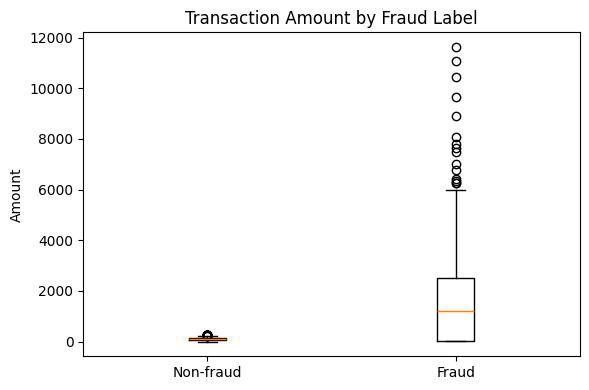

In [ ]:
# Step 3.4: Amount distribution by fraud vs non-fraud
plt.figure(figsize=(6,4))
plt.boxplot(
    [df[df['is_fraud']==0]['amount'], df[df['is_fraud']==1]['amount']],
    labels=['Non-fraud', 'Fraud']
)
plt.title("Transaction Amount by Fraud Label")
plt.ylabel("Amount")
plt.tight_layout()
plt.show()


Elbow Method to Pick K

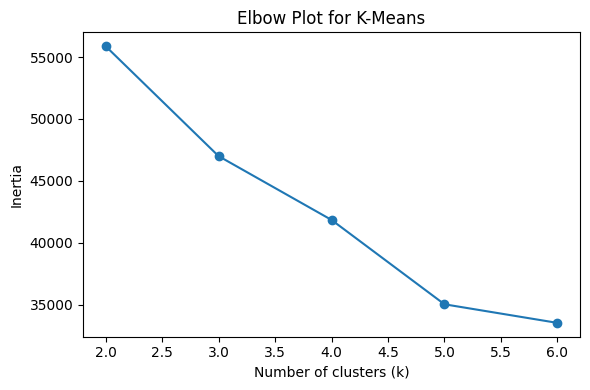

In [ ]:
# Ensure X is the correctly processed numerical data
X = preprocessor.fit_transform(df)

# Step 4.1: Elbow method (optional)
inertias = []
ks = range(2, 7)

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertias.append(km.inertia_)

plt.figure(figsize=(6,4))
plt.plot(ks, inertias, marker='o')
plt.title("Elbow Plot for K-Means")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.tight_layout()
plt.show()

Fit K-means

In [ ]:
# Ensure X is the correctly processed numerical data
X = preprocessor.fit_transform(df)

# Step 4.2: Fit final K-Means model
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df['kmeans_cluster'] = kmeans.fit_predict(X)

df[['transaction_id', 'amount', 'is_fraud', 'kmeans_cluster']].head()

,transaction_id,amount,is_fraud,kmeans_cluster
0,9608,4922.587542,1,1
1,456,48.018303,0,2
2,4747,136.881960,0,0
3,6934,80.534719,0,2
4,1646,120.041158,0,2


Evaluate and Interpret K-Means Clusters

K-Means cluster profile:


,n_transactions,avg_amount,fraud_rate,avg_risk_index,pct_high_amount,pct_night_txn
kmeans_cluster,,,,,,
0,3695,80.833567,0.0,0.148839,0.000,0.000
1,500,1657.577984,1.0,0.854860,0.724,0.386
2,3667,81.034773,0.0,0.150178,0.000,0.000
3,2138,166.886853,0.0,0.146920,1.000,0.000


K-Means: transaction type distribution by cluster (row-wise %):


transaction_type,ATM,Online,POS,QR
kmeans_cluster,,,,
0,0.244926,0.242760,0.261705,0.250609
1,0.276000,0.252000,0.232000,0.240000
2,0.256340,0.230706,0.263703,0.249250
3,0.255379,0.246960,0.242283,0.255379


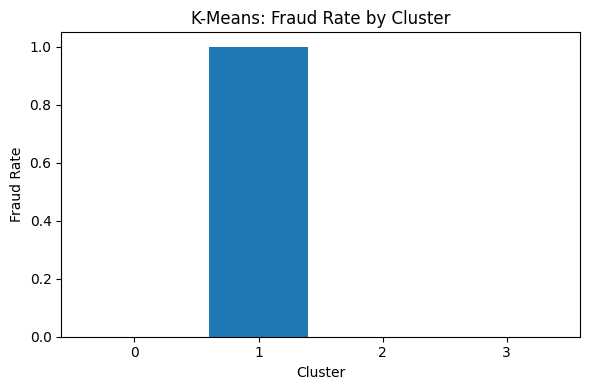

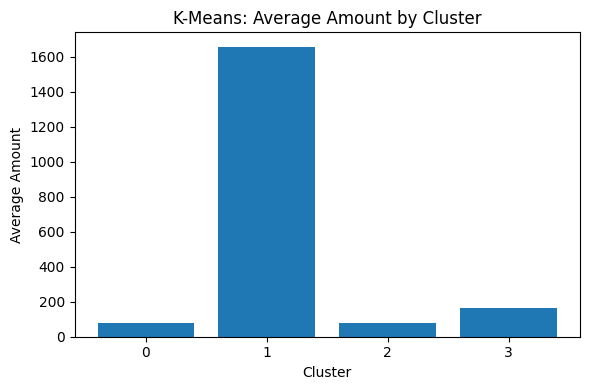

In [ ]:
# Step 4.3: Cluster profiling for K-Means
# Ensure 'kmeans_cluster' exists in df
if 'kmeans_cluster' not in df.columns:
    # Re-run K-Means prediction if the column is missing
    # This assumes 'kmeans' and 'X' are still defined from previous steps
    k = 4 # or retrieve from 'kmeans' object if available
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # Re-initialize if not in scope
    df['kmeans_cluster'] = kmeans.fit_predict(X)

kmeans_profile = df.groupby('kmeans_cluster').agg(
    n_transactions=('transaction_id', 'count'),
    avg_amount=('amount', 'mean'),
    fraud_rate=('is_fraud', 'mean'),
    avg_risk_index=('risk_index', 'mean'),
    pct_high_amount=('high_amount', 'mean'),
    pct_night_txn=('night_txn', 'mean')
)

print("K-Means cluster profile:")
display(kmeans_profile)

# Transaction type mix by cluster
kmeans_tt = pd.crosstab(df['kmeans_cluster'], df['transaction_type'])
kmeans_tt_pct = kmeans_tt.div(kmeans_tt.sum(axis=1), axis=0)

print("K-Means: transaction type distribution by cluster (row-wise %):")
display(kmeans_tt_pct)

# Plot fraud rate by cluster
plt.figure(figsize=(6,4))
plt.bar(kmeans_profile.index.astype(str), kmeans_profile['fraud_rate'])
plt.title("K-Means: Fraud Rate by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Fraud Rate")
plt.tight_layout()
plt.show()

# Plot average amount by cluster
plt.figure(figsize=(6,4))
plt.bar(kmeans_profile.index.astype(str), kmeans_profile['avg_amount'])
plt.title("K-Means: Average Amount by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Amount")
plt.tight_layout()
plt.show()

KPI Proxies per Transaction

In [ ]:
import numpy as np
import pandas as pd

# ---------- CONFIG: set reasonable business assumptions ----------
# (Adjust these to match your report narrative)
CHARGEBACK_FEE = 25.0                 # $ per fraud chargeback event
FRAUD_LOSS_MULTIPLIER = 1.0           # assume you lose ~100% of fraud amount (simplified)
MANUAL_REVIEW_COST = 2.50             # $ per manual review
STEP_UP_COST = 0.10                   # $ operational cost per step-up auth (SMS/OTP etc.)
MARGIN_RATE = 0.02                    # assume 2% net margin on legitimate transactions (proxy)

# A simple "friction rule": if risk_mean high OR very high amount => likely trigger additional checks
RISK_STEPUP_THRESHOLD = 0.70
AMOUNT_STEPUP_THRESHOLD = df_out["amount"].quantile(0.95)

df_kpi = df_out.copy()

# ---------- Transaction-level KPI proxies ----------
df_kpi["step_up_flag"] = ((df_kpi["risk_mean"] >= RISK_STEPUP_THRESHOLD) |
                          (df_kpi["amount"] >= AMOUNT_STEPUP_THRESHOLD)).astype(int)

df_kpi["step_up_cost"] = df_kpi["step_up_flag"] * STEP_UP_COST
df_kpi["manual_review_cost"] = df_kpi["step_up_flag"] * MANUAL_REVIEW_COST

# If you have is_fraud, estimate fraud costs; if not, use risk_mean as an expected-loss proxy
if "is_fraud" in df_kpi.columns:
    df_kpi["fraud_loss"] = df_kpi["is_fraud"] * (df_kpi["amount"] * FRAUD_LOSS_MULTIPLIER + CHARGEBACK_FEE)
else:
    # Expected fraud loss proxy: risk_mean * amount * factor
    EXPECTED_LOSS_FACTOR = 0.15  # tune: expected percent of amount lost at risk_mean=1.0
    df_kpi["fraud_loss"] = df_kpi["risk_mean"] * df_kpi["amount"] * EXPECTED_LOSS_FACTOR

# Revenue proxy: treat amount as gross transaction value; profit proxy uses margin_rate net on non-fraud
if "is_fraud" in df_kpi.columns:
    df_kpi["profit_proxy"] = (1 - df_kpi["is_fraud"]) * (df_kpi["amount"] * MARGIN_RATE) \
                             - df_kpi["fraud_loss"] - df_kpi["manual_review_cost"] - df_kpi["step_up_cost"]
else:
    df_kpi["profit_proxy"] = (df_kpi["amount"] * MARGIN_RATE) \
                             - df_kpi["fraud_loss"] - df_kpi["manual_review_cost"] - df_kpi["step_up_cost"]

df_kpi.head()


,transaction_id,user_id,amount,transaction_type,merchant_category,country,hour,device_risk_score,ip_risk_score,is_fraud,...,log_amount,risk_sum,risk_mean,high_amount_flag,cluster,step_up_flag,step_up_cost,manual_review_cost,fraud_loss,profit_proxy
0,9608,363,4922.587542,ATM,Travel,TR,12,0.992347,0.947908,1,...,8.501793,1.940254,0.970127,1,1,1,0.1,2.5,4947.587542,-4950.187542
1,456,692,48.018303,QR,Food,US,21,0.168571,0.224057,0,...,3.892194,0.392629,0.196314,0,0,0,0.0,0.0,0.000000,0.960366
2,4747,587,136.881960,Online,Travel,TR,14,0.296127,0.125058,0,...,4.926398,0.421185,0.210592,0,0,0,0.0,0.0,0.000000,2.737639
3,6934,445,80.534719,POS,Clothing,TR,23,0.124801,0.159243,0,...,4.401029,0.284043,0.142022,0,0,0,0.0,0.0,0.000000,1.610694
4,1646,729,120.041158,Online,Grocery,FR,16,0.098129,0.027542,0,...,4.796131,0.125671,0.062835,0,0,0,0.0,0.0,0.000000,2.400823


In [ ]:
Cluster KPi Dashboard Table

In [ ]:
cluster_kpis = df_kpi.groupby("cluster").agg(
    n=("cluster","size"),
    total_value=("amount","sum"),
    avg_amount=("amount","mean"),
    high_amount_rate=("high_amount_flag","mean"),
    avg_risk=("risk_mean","mean"),
    step_up_rate=("step_up_flag","mean"),
    fraud_cost=("fraud_loss","sum"),
    review_cost=("manual_review_cost","sum"),
    step_up_cost=("step_up_cost","sum"),
    profit_proxy=("profit_proxy","sum"),
).reset_index()

# Make it presentation-friendly
cluster_kpis["high_amount_rate"] = (cluster_kpis["high_amount_rate"]*100).round(2)
cluster_kpis["step_up_rate"] = (cluster_kpis["step_up_rate"]*100).round(2)
cluster_kpis["total_value"] = cluster_kpis["total_value"].round(2)
cluster_kpis["avg_amount"] = cluster_kpis["avg_amount"].round(2)
cluster_kpis["avg_risk"] = cluster_kpis["avg_risk"].round(3)
cluster_kpis["fraud_cost"] = cluster_kpis["fraud_cost"].round(2)
cluster_kpis["review_cost"] = cluster_kpis["review_cost"].round(2)
cluster_kpis["step_up_cost"] = cluster_kpis["step_up_cost"].round(2)
cluster_kpis["profit_proxy"] = cluster_kpis["profit_proxy"].round(2)

cluster_kpis.sort_values("profit_proxy", ascending=False)


,cluster,n,total_value,avg_amount,high_amount_rate,avg_risk,step_up_rate,fraud_cost,review_cost,step_up_cost,profit_proxy
0,0,9500,952638.64,100.28,6.76,0.149,1.55,0.00,367.5,14.7,18670.57
1,1,500,828788.99,1657.58,71.60,0.855,100.00,841288.99,1250.0,50.0,-842588.99


#5. Managerial Insights Per Cluster

In [ ]:
def insight_generator(row):
    insights = []
    actions = []
    kpi_links = []

    # Revenue tier
    if row["total_value"] >= cluster_kpis["total_value"].quantile(0.75):
        insights.append("High contribution to transaction value (revenue proxy).")
        actions.append("Retention + upsell strategy: loyalty offers, preferred customer experience, targeted cross-sell.")
        kpi_links.append("KPI: protect revenue / grow ARPU (avg revenue per user proxy).")
    elif row["total_value"] <= cluster_kpis["total_value"].quantile(0.25):
        insights.append("Low contribution to transaction value (revenue proxy).")
        actions.append("Low-cost engagement strategy: automated onboarding, light-touch communications.")
        kpi_links.append("KPI: reduce servicing cost per customer/transaction.")

    # Risk & cost tier
    if row["avg_risk"] >= cluster_kpis["avg_risk"].quantile(0.75):
        insights.append("Above-average risk profile.")
        actions.append("Process optimization: tighter fraud rules, step-up authentication, monitoring, merchant/channel controls.")
        kpi_links.append("KPI: reduce fraud loss and chargeback costs.")
    elif row["avg_risk"] <= cluster_kpis["avg_risk"].quantile(0.25):
        insights.append("Low risk profile.")
        actions.append("Reduce friction: fewer step-ups, smoother checkout to improve conversion.")
        kpi_links.append("KPI: improve customer satisfaction + conversion rate.")

    # Friction / CSAT proxy
    if row["step_up_rate"] >= cluster_kpis["step_up_rate"].quantile(0.75):
        insights.append("High expected authentication friction (step-up rate).")
        actions.append("Optimize experience: risk-based authentication tuning, whitelist trusted patterns, faster verification UX.")
        kpi_links.append("KPI: CSAT/NPS proxy via lower friction and fewer false declines.")
    elif row["step_up_rate"] <= cluster_kpis["step_up_rate"].quantile(0.25):
        insights.append("Low expected friction.")
        actions.append("Keep current controls; consider expanding limits or offering premium features.")
        kpi_links.append("KPI: increase successful transaction completion rate.")

    # Profit proxy (manager headline)
    if row["profit_proxy"] >= cluster_kpis["profit_proxy"].quantile(0.75):
        insights.append("Strong profit proxy after risk/control costs.")
        actions.append("Prioritize as a 'protect & grow' segment; invest in retention and personalization.")
        kpi_links.append("KPI: profit / margin expansion.")
    elif row["profit_proxy"] <= cluster_kpis["profit_proxy"].quantile(0.25):
        insights.append("Weak profit proxy driven by higher loss/control costs or low value.")
        actions.append("Contain costs: adjust thresholds, improve detection precision, reduce manual handling.")
        kpi_links.append("KPI: cost savings and operational efficiency.")

    return " ".join(insights), " ".join(actions), " ".join(kpi_links)

insight_rows = []
for _, r in cluster_kpis.iterrows():
    ins, act, kpi = insight_generator(r)
    insight_rows.append({
        "cluster": int(r["cluster"]),
        "managerial_insights": ins,
        "recommended_actions": act,
        "kpi_connection": kpi
    })

insight_table = pd.DataFrame(insight_rows).sort_values("cluster")
insight_table


,cluster,managerial_insights,recommended_actions,kpi_connection
0,0,High contribution to transaction value (revenu...,"Retention + upsell strategy: loyalty offers, p...",KPI: protect revenue / grow ARPU (avg revenue ...
1,1,Low contribution to transaction value (revenue...,Low-cost engagement strategy: automated onboar...,KPI: reduce servicing cost per customer/transa...


In [ ]:
Revenue vs. Risk by Cluster

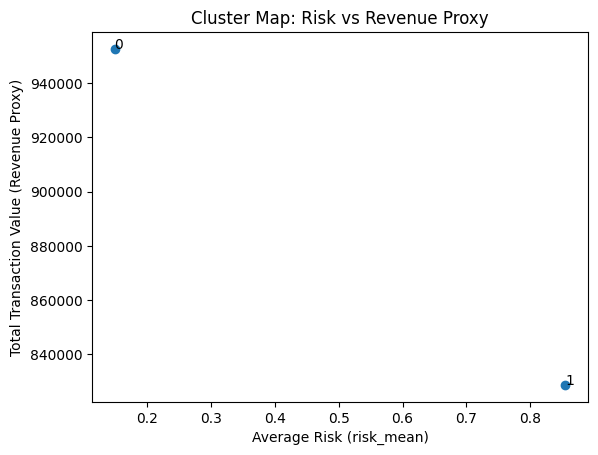

In [ ]:
plt.figure()
plt.scatter(cluster_kpis["avg_risk"], cluster_kpis["total_value"])
for _, r in cluster_kpis.iterrows():
    plt.text(r["avg_risk"], r["total_value"], str(int(r["cluster"])))
plt.title("Cluster Map: Risk vs Revenue Proxy")
plt.xlabel("Average Risk (risk_mean)")
plt.ylabel("Total Transaction Value (Revenue Proxy)")
plt.show()


Fraud/ Control Cost vs. Profit Proxy

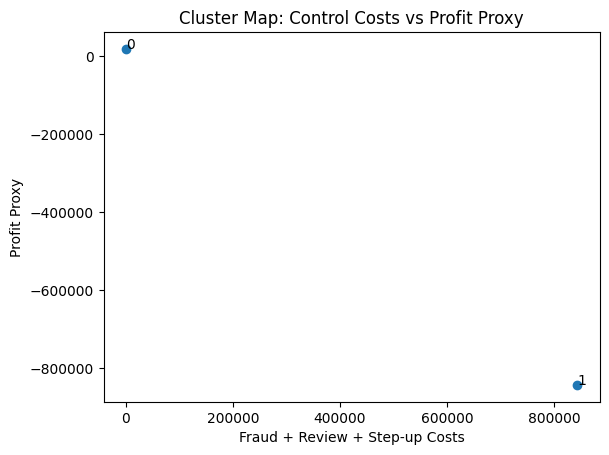

In [ ]:
plt.figure()
total_control_cost = cluster_kpis["fraud_cost"] + cluster_kpis["review_cost"] + cluster_kpis["step_up_cost"]
plt.scatter(total_control_cost, cluster_kpis["profit_proxy"])
for _, r in cluster_kpis.iterrows():
    plt.text(total_control_cost.loc[r.name], r["profit_proxy"], str(int(r["cluster"])))
plt.title("Cluster Map: Control Costs vs Profit Proxy")
plt.xlabel("Fraud + Review + Step-up Costs")
plt.ylabel("Profit Proxy")
plt.show()


#6.Advanced Extensions

Step 1: Load and Explore Data

Data loaded successfully! First 5 rows:


,transaction_id,user_id,amount,transaction_type,merchant_category,country,hour,device_risk_score,ip_risk_score,is_fraud
0,9608,363,4922.587542,ATM,Travel,TR,12,0.992347,0.947908,1
1,456,692,48.018303,QR,Food,US,21,0.168571,0.224057,0
2,4747,587,136.881960,Online,Travel,TR,14,0.296127,0.125058,0
3,6934,445,80.534719,POS,Clothing,TR,23,0.124801,0.159243,0
4,1646,729,120.041158,Online,Grocery,FR,16,0.098129,0.027542,0



Data Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   transaction_id     10000 non-null  int64  
 1   user_id            10000 non-null  int64  
 2   amount             10000 non-null  float64
 3   transaction_type   10000 non-null  object 
 4   merchant_category  10000 non-null  object 
 5   country            10000 non-null  object 
 6   hour               10000 non-null  int64  
 7   device_risk_score  10000 non-null  float64
 8   ip_risk_score      10000 non-null  float64
 9   is_fraud           10000 non-null  int64  
dtypes: float64(3), int64(4), object(3)
memory usage: 781.4+ KB

Is_Fraud Distribution:
is_fraud
0    0.95
1    0.05
Name: proportion, dtype: float64


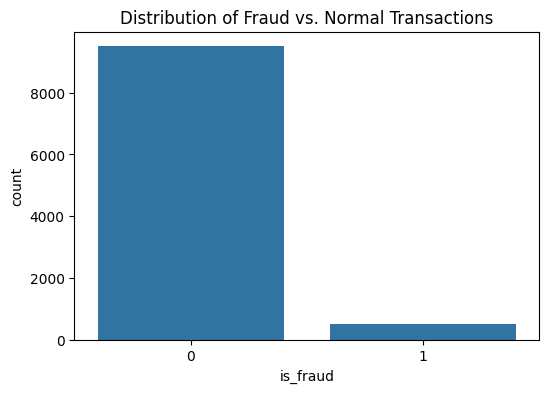

In [20]:
# Step 1: Load and Explore Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# TODO: Assume you have downloaded the dataset and named it 'synthetic_financial_fraud_dataset.csv'
# Please replace the placeholder path with your actual file path if needed.
FILE_PATH = '/content/synthetic_fraud_dataset.csv'

try:
    df = pd.read_csv(FILE_PATH)
    print("Data loaded successfully! First 5 rows:")
    display(df.head())
    print("\nData Information:")
    df.info()
except FileNotFoundError:
    print(f"Error: File '{FILE_PATH}' not found. Please check the file path.")

# Check the distribution of the target variable
# 'Is_Fraud' is usually highly imbalanced in fraud datasets
print("\nIs_Fraud Distribution:")
print(df['is_fraud'].value_counts(normalize=True))

# Visualize the imbalance
plt.figure(figsize=(6, 4))
sns.countplot(x='is_fraud', data=df)
plt.title('Distribution of Fraud vs. Normal Transactions')
plt.show()

Step 2: Outlier Detection (Fraud Detection)

2.1 Data Preprocessing

In [21]:
# Step 2.1: Preprocess Data for Isolation Forest
from sklearn.preprocessing import LabelEncoder

# Copy DataFrame for manipulation
fraud_df = df.copy()

# The target variable is 'is_fraud' (1 = Fraud/Anomaly, 0 = Normal)
y_fraud = fraud_df['is_fraud']

# Identify categorical columns that need encoding
# Based on common columns in this dataset: 'type', 'nameOrig', 'nameDest' are usually categorical.
# We will drop high-cardinality ID columns like 'nameOrig' and 'nameDest' for simplicity,
# or we could encode them if computational resources allow.
cols_to_drop = ['is_fraud', 'isFlaggedFraud', 'nameOrig', 'nameDest'] # Dropping IDs and targets
X_fraud = fraud_df.drop(columns=cols_to_drop, errors='ignore')

# Identify categorical columns that are still of 'object' dtype
categorical_cols = X_fraud.select_dtypes(include=['object']).columns

# Convert identified categorical columns to numerical using One-Hot Encoding
X_fraud = pd.get_dummies(X_fraud, columns=categorical_cols, drop_first=True)

# Handle missing values (if any)
X_fraud.fillna(X_fraud.median(), inplace=True)

print("Features ready for Isolation Forest:")
print(X_fraud.head())

Features ready for Isolation Forest:
   transaction_id  user_id       amount  hour  device_risk_score  \
0            9608      363  4922.587542    12           0.992347   
1             456      692    48.018303    21           0.168571   
2            4747      587   136.881960    14           0.296127   
3            6934      445    80.534719    23           0.124801   
4            1646      729   120.041158    16           0.098129   

   ip_risk_score  transaction_type_Online  transaction_type_POS  \
0       0.947908                    False                 False   
1       0.224057                    False                 False   
2       0.125058                     True                 False   
3       0.159243                    False                  True   
4       0.027542                     True                 False   

   transaction_type_QR  merchant_category_Electronics  merchant_category_Food  \
0                False                          False                 

2.2 Run Isolation Forest and Evaluate

Setting contamination to actual fraud rate: 0.0500
Training Isolation Forest...

--- Isolation Forest Fraud Detection Results ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9500
           1       0.96      0.96      0.96       500

    accuracy                           1.00     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       1.00      1.00      1.00     10000

F1-Score (Macro Average): 0.9811


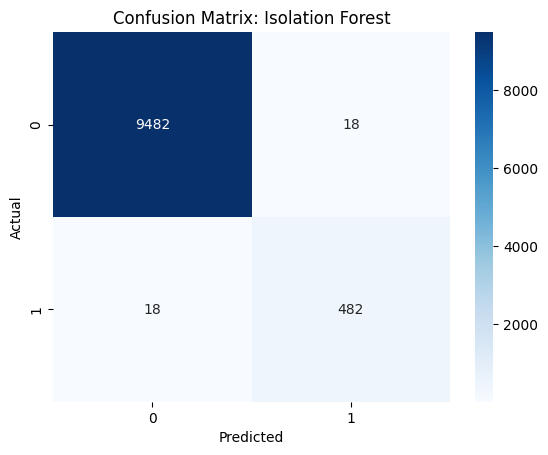

In [22]:
# Step 2.2: Run Isolation Forest for Anomaly Detection

from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, f1_score, confusion_matrix

# Isolation Forest Model Initialization
# 'contamination' is the expected proportion of outliers (fraud) in the dataset.
actual_fraud_rate = df['is_fraud'].mean()
print(f"Setting contamination to actual fraud rate: {actual_fraud_rate:.4f}")

iso_forest = IsolationForest(
    contamination=actual_fraud_rate,
    random_state=42,
    n_estimators=100,
    n_jobs=-1 # Use all CPU cores
)

# Train the model
print("Training Isolation Forest...")
iso_forest.fit(X_fraud)

# Predict anomalies (-1 for anomaly/fraud, 1 for normal)
y_pred_anomaly = iso_forest.predict(X_fraud)

# Convert predictions to match the 0/1 format of 'is_fraud'
y_pred_fraud = np.where(y_pred_anomaly == -1, 1, 0)

# Evaluate model performance
print("\n--- Isolation Forest Fraud Detection Results ---")
print(classification_report(y_fraud, y_pred_fraud))
print(f"F1-Score (Macro Average): {f1_score(y_fraud, y_pred_fraud, average='macro'):.4f}")

# Confusion Matrix
cm = confusion_matrix(y_fraud, y_pred_fraud)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: Isolation Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Step 3: Association Rule Mining (Market Basket Analysis)

In [23]:
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings("ignore")

# 1. Load Data
# Ensure the file name matches your uploaded file
df = pd.read_csv('/content/synthetic_fraud_dataset.csv')

# 2. Data Preparation: Filter for Fraudulent Transactions only
# We only want to analyze patterns within fraud cases (is_fraud == 1)
fraud_df = df[df['is_fraud'] == 1].copy()

# 3. Discretize the 'amount' column
# We convert the numerical 'amount' into categorical bins: Low, Medium, High
if 'amount' in fraud_df.columns:
    fraud_df['amount_cat'] = pd.qcut(
        fraud_df['amount'],
        q=3,
        labels=['Amount=Low', 'Amount=Medium', 'Amount=High'],
        duplicates='drop'
    )

# 4. Construct the Transaction List
# We create a list of lists, where each inner list represents a transaction
# containing the 'transaction_type' and the 'amount_category'.
transactions = []
for index, row in fraud_df.iterrows():
    itemset = []

    # Add Transaction Type (using the correct column name 'transaction_type')
    if 'transaction_type' in row:
        itemset.append(f"Type={row['transaction_type']}")

    # Add Amount Category
    if 'amount_cat' in row:
        itemset.append(str(row['amount_cat']))

    if len(itemset) > 0:
        transactions.append(itemset)

print(f"Number of fraud transactions analyzing: {len(transactions)}")

# 5. Encode Data for Apriori
# Convert the list of transactions into a One-Hot Encoded DataFrame
te = TransactionEncoder()
te_data = te.fit(transactions).transform(transactions)
df_encoded = pd.DataFrame(te_data, columns=te.columns_)

# 6. Run Apriori Algorithm to find Frequent Itemsets
# min_support=0.01 means the itemset must appear in at least 1% of fraud cases
frequent_itemsets = apriori(df_encoded, min_support=0.01, use_colnames=True)

# 7. Generate Association Rules
# min_threshold=0.1 means we want rules with at least 10% confidence
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.1)

# 8. Filter and Display Results
# We sort by 'lift' (Lift > 1 indicates a positive correlation)
if not rules.empty:
    top_rules = rules.sort_values(['lift', 'confidence'], ascending=False).head(5)

    print("\n--- Top Association Rules in Fraud Transactions ---")

    # Clean up the output for better readability
    cols = ['antecedents', 'consequents', 'support', 'confidence', 'lift']
    display_rules = top_rules[cols].copy()

    # Convert frozensets to strings for display
    display_rules['antecedents'] = display_rules['antecedents'].apply(lambda x: list(x)[0])
    display_rules['consequents'] = display_rules['consequents'].apply(lambda x: list(x)[0])

    # Display using Markdown for a nice table format
    print(display_rules.to_markdown(index=False))
else:
    print("No strong association rules found matching the thresholds.")

Number of fraud transactions analyzing: 500

--- Top Association Rules in Fraud Transactions ---
| antecedents   | consequents   |   support |   confidence |    lift |
|:--------------|:--------------|----------:|-------------:|--------:|
| Amount=Medium | Type=Online   |     0.1   |     0.301205 | 1.19526 |
| Type=Online   | Amount=Medium |     0.1   |     0.396825 | 1.19526 |
| Type=QR       | Amount=High   |     0.088 |     0.366667 | 1.0978  |
| Amount=High   | Type=QR       |     0.088 |     0.263473 | 1.0978  |
| Type=ATM      | Amount=High   |     0.1   |     0.362319 | 1.08479 |
